# EX6 ANN MNIST

In [1]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as opt
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms import transforms

## data preparation

In [2]:
train_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=True,transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST("../DATA/",download=True,train=False,transform=transforms.ToTensor())


let's visualize

Text(0.5, 1.0, '5')

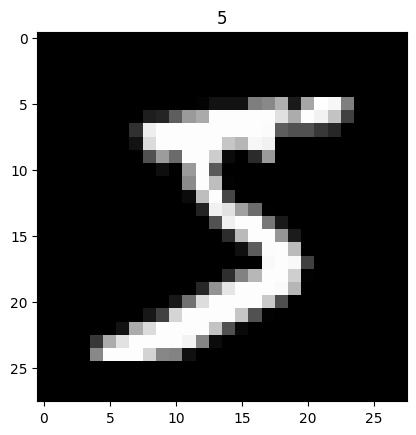

In [3]:
plt.imshow(train_dataset.data[0],cmap='gray')
plt.title(str(train_dataset.targets[0].item()))


data processing continued

In [4]:
print(f'train x shape {train_dataset.data.shape} y_train {train_dataset.targets.shape}\ntest x shape {test_dataset.data.shape} y_test {test_dataset.targets.shape}')

train x shape torch.Size([60000, 28, 28]) y_train torch.Size([60000])
test x shape torch.Size([10000, 28, 28]) y_test torch.Size([10000])


In [5]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=128,shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,batch_size=128,shuffle=False)

## build the model

In [6]:
model = nn.Sequential(
    nn.Linear(28*28,128),
    nn.ReLU(),
    nn.Linear(128,10)
    # nn.Softmax() - not needed 
)

## set device to GPU(if exists)

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device=device)

cuda:0


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = opt.Adam(model.parameters(),lr=0.0001)

## Training the model

In [9]:
EPOCHS = 10
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(EPOCHS): 
    n_correct = 0
    n_total = 0
    train_loss = []
    # 0. batch loop 
    for inputs,targets in train_loader:
        #1. zero gradients  that optimizer are in charge
        optimizer.zero_grad()
        
        # put inputs and targets into device(GPU)
        inputs,targets = inputs.to(device),targets.to(device)

        # flatten the input (because it's ANN NxD)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)

        loss = criterion(outputs,targets)
        loss.backward()
        optimizer.step()
        _,indxs = torch.max(outputs,1)
        
        #calculate accuracy
        with torch.no_grad():
            n_total += indxs.shape[0]
            n_correct +=np.sum(indxs.cpu().numpy() == targets.cpu().numpy())
        #batch loss
        train_loss.append(loss.item())

    train_losses.append(np.mean(train_loss))
    train_accuracy.append(n_correct/n_total)
    test_loss = []
    #test
    n_correct = 0
    n_total = 0
    for inputs,targets in test_loader:
        inputs,targets = inputs.to(device),targets.to(device)
        inputs = inputs.view(-1,28*28)

        outputs = model(inputs)
        loss = criterion(outputs,targets)
        test_loss.append(loss.item())
        _,indxs = torch.max(outputs,1)

    #calculate accuracy
        with torch.no_grad():
            n_total += indxs.shape[0]
            n_correct +=np.sum(indxs.cpu().numpy() == targets.cpu().numpy())
    test_losses.append(np.mean(test_loss))
    test_accuracy.append(n_correct/n_total)


    print(f'train_loss {train_losses[-1]} test_loss {test_losses[-1]} train acc: {train_accuracy[-1]} test acc: {test_accuracy[-1]}')
    #acc = n_correct /n_total

train_loss 1.178665007863726 test_loss 0.5718004001846796 train acc: 0.7745333333333333 test acc: 0.8744
train_loss 0.47236552097395795 test_loss 0.381501622215102 train acc: 0.8841 test acc: 0.9021
train_loss 0.36310250361336827 test_loss 0.31962530380940135 train acc: 0.90275 test acc: 0.914
train_loss 0.31725658603441487 test_loss 0.28979818702121324 train acc: 0.9128833333333334 test acc: 0.92
train_loss 0.2894980669466417 test_loss 0.26802569071326077 train acc: 0.91915 test acc: 0.9243
train_loss 0.2689260508078756 test_loss 0.25316337095219876 train acc: 0.9247333333333333 test acc: 0.9289
train_loss 0.25241965200029204 test_loss 0.2387311344235381 train acc: 0.9296666666666666 test acc: 0.9327
train_loss 0.23809525184730476 test_loss 0.22853879437227792 train acc: 0.9337333333333333 test acc: 0.9352
train_loss 0.22550718128871816 test_loss 0.21657313497241917 train acc: 0.9373666666666667 test acc: 0.9391
train_loss 0.21409700278724944 test_loss 0.20701077901109866 train acc: 0

In [10]:
#predict:

# _,predictions = torch.max(outputs,1)

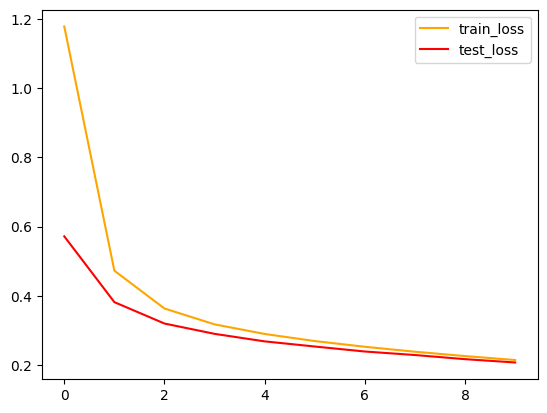

In [11]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_losses,label='train_loss',color='orange')
plt.plot(x,test_losses,label='test_loss',color='red')
plt.legend()

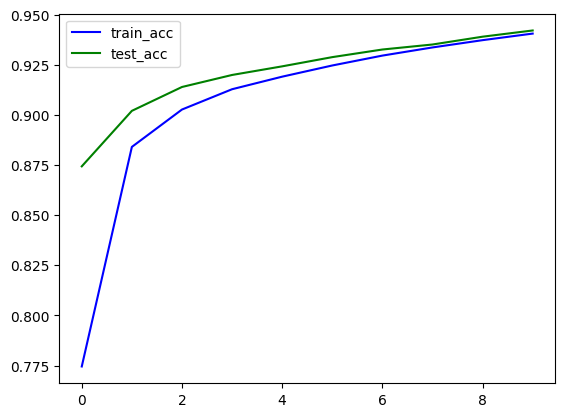

In [12]:
x = [i for i in range(EPOCHS)]
plt.plot(x,train_accuracy,label='train_acc',color='blue')
plt.plot(x,test_accuracy,label='test_acc',color='green')
plt.legend()